<a href="https://www.kaggle.com/code/ibrahimabdelsattar10/mall-customers-segmentation?scriptVersionId=283418324" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

## Import Necessary Python Libraries 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

### Read the Dataset

In [2]:
df=pd.read_csv('/kaggle/input/mall-customers-segmentation/Mall_Customers.csv')

### Show the first 5 rows

In [3]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


<div style="border-radius:10px; border:#808080 solid; padding: 15px; background-color:##F0E68C ; font-size:100%; text-align:left">

## 🛍️ Mall Customers Dataset Overview

This dataset contains demographic and behavioral information for **200 customers** who visit a mall. It is commonly used for **exploratory data analysis (EDA)**, **customer segmentation**, and **clustering techniques** such as **K-Means**.

---

### 📦 Dataset Summary

- **Total Records:** 200  
- **Number of Features:** 5  
- **Missing Values:** None

---

### 🔍 Feature Descriptions

| Column Name                | Description                                                                 |
|---------------------------|-----------------------------------------------------------------------------|
| `CustomerID`              | A unique integer identifier for each customer                              |
| `Genre`                   | The gender of the customer (`Male` / `Female`)                              |
| `Age`                     | Age of the customer (in years)                                              |
| `Annual Income (k$)`      | Customer's annual income in thousands of US dollars                         |
| `Spending Score (1-100)`  | Score assigned by the mall based on customer spending behavior and patterns |

---

### 🎯 Potential Use Cases

- **Customer Segmentation:** Cluster customers based on their spending habits and income levels.
- **Behavioral Analysis:** Examine how demographics (e.g., age, gender) influence spending behavior.
- **Targeted Marketing:** Identify different customer groups for personalized promotions.
- **Clustering Algorithms:** Apply techniques like K-Means to detect patterns in customer behavior.

---

### ❓ Exploratory Questions

- What is the relationship between annual income and spending score?  
- Does gender or age influence spending behavior?  
- Which customers have high spending scores but low incomes, or vice versa?


### Rename the columns

In [4]:
df.rename(columns={'Genre':'Gender','Annual Income (k$)':'Income','Spending Score (1-100)':'Spending_Score'},inplace=True)

### Show some information about the dataset

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   CustomerID      200 non-null    int64 
 1   Gender          200 non-null    object
 2   Age             200 non-null    int64 
 3   Income          200 non-null    int64 
 4   Spending_Score  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


### Show some statistics information

In [6]:
df.describe()

,CustomerID,Age,Income,Spending_Score
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## Checking for missing values

In [7]:
df.isna().sum()

CustomerID        0
Gender            0
Age               0
Income            0
Spending_Score    0
dtype: int64

### Checking for outliers

In [8]:
df.duplicated().sum()

0

In [9]:
cols=['Age','Income','Spending_Score']

### Checking for Outliers

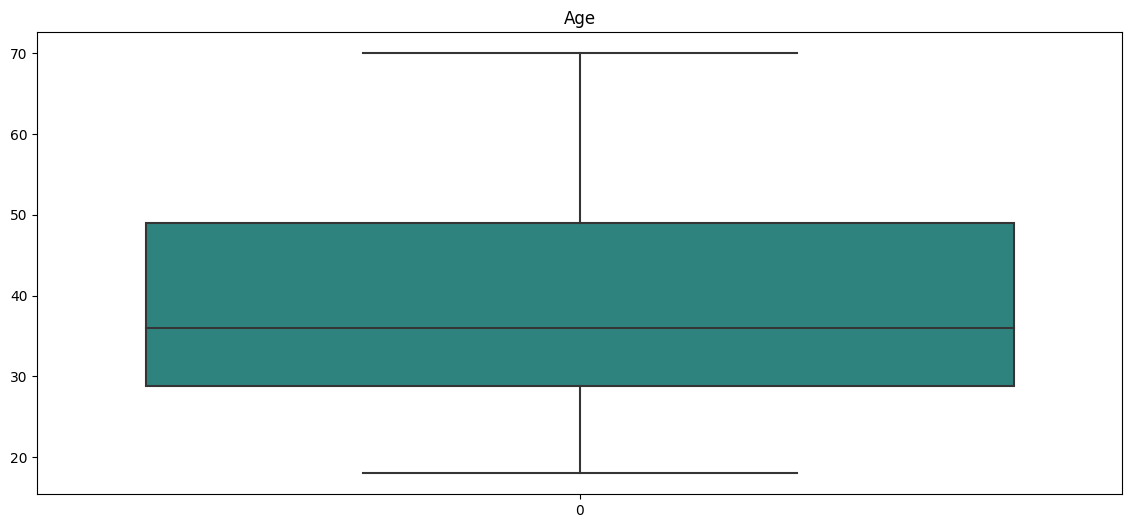

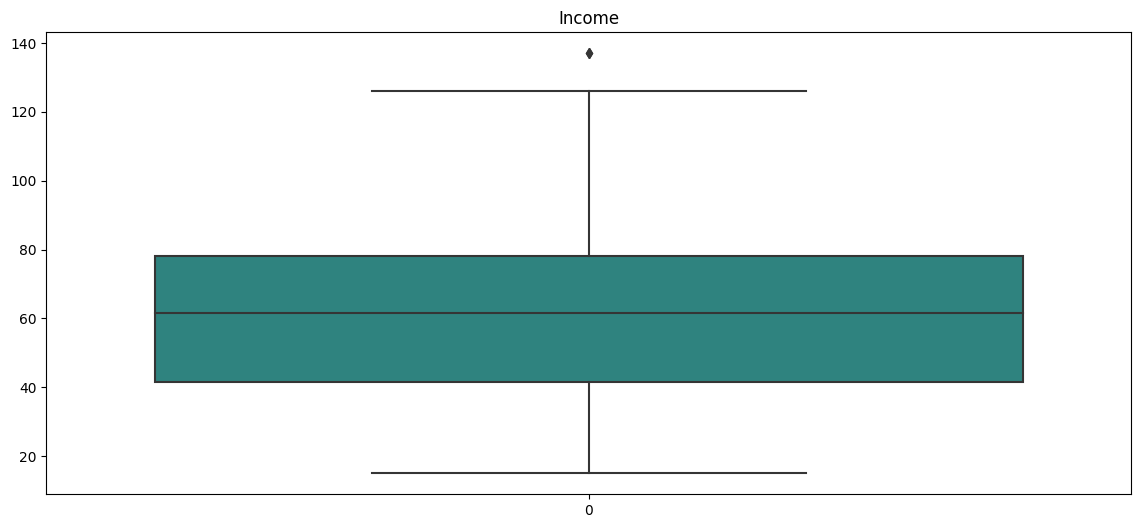

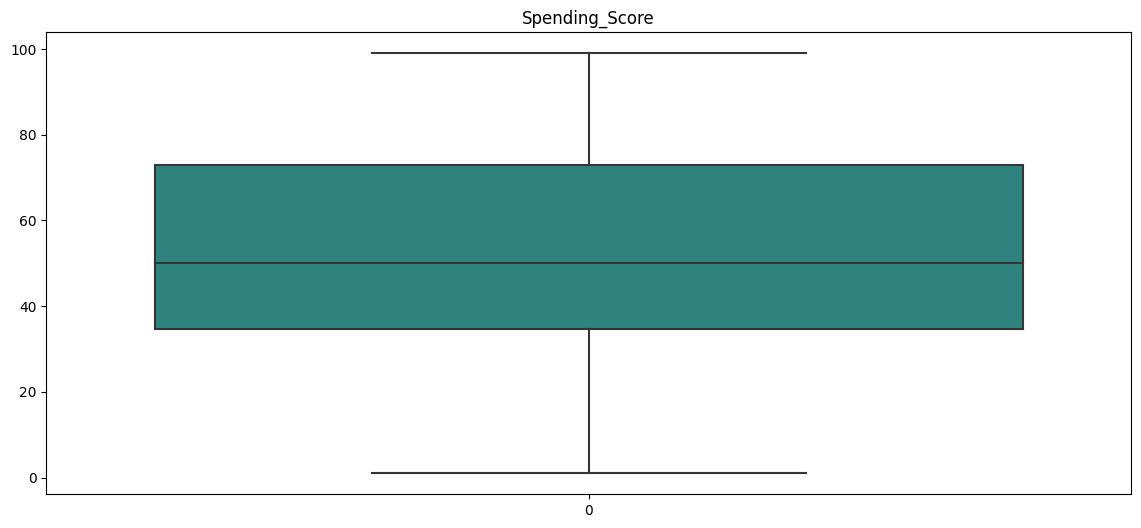

In [10]:
for col in cols:
    plt.figure(figsize=(14,6))
    sns.boxplot(df[col],palette='viridis')
    plt.title(col)
    plt.show()

### Drop unneeded columns

In [11]:
df.drop(columns='CustomerID',inplace=True)

# **Univariate Analysis**

## Distribution of Age

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


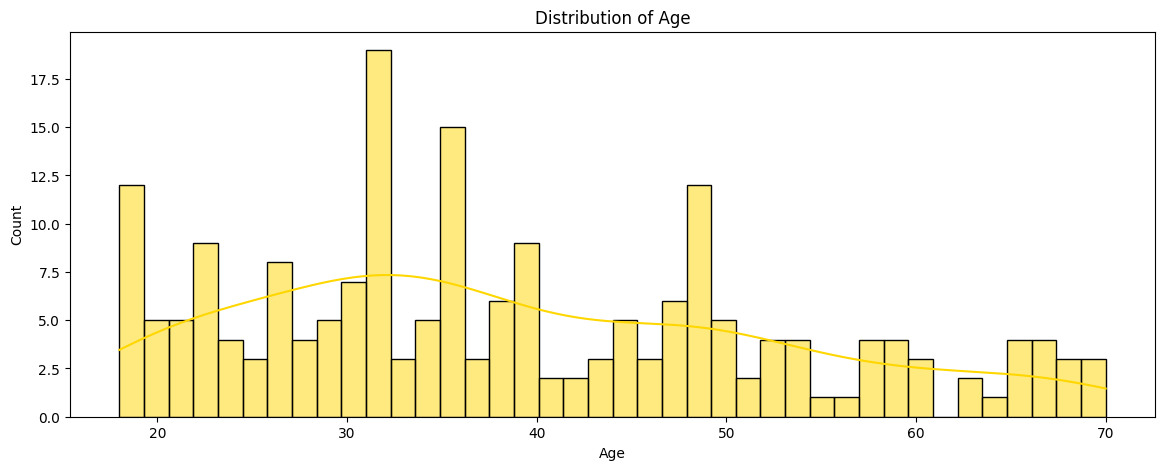

In [12]:
plt.figure(figsize=(14, 5))
sns.histplot(df['Age'], bins=40, kde=True,color='gold')
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

<div style="border-radius:10px; border:#808080 solid; padding: 15px; background-color:##F0E68C ; font-size:100%; text-align:left">

## 📊 Distribution of Age: Insights & Business Implications

### **Chart Overview:**
The following chart displays the **distribution of customer ages** in the dataset. It uses a **histogram** with an overlaid **kernel density estimate (KDE)** to give us a smooth representation of the age distribution. The histogram is divided into **30 bins**, which helps visualize the spread and concentration of customer ages across the dataset.

### **Key Insights:**
1. **Peak in Younger Demographics:**
   - The **highest frequency** of customers is observed in the **early 30s**, with ages such as **32, 35, 19, and 31** having the largest counts.
   - This indicates that the mall has a **strong representation of customers** in the **20 to 40 age range**, making them the core audience.

2. **Declining Representation in Older Demographics:**
   - As we move into the **50+ age group**, the frequency of customers declines significantly.
   - Customers in their **60s and 70s** still exist in the dataset but in **low numbers**, suggesting that the mall may attract fewer older customers.

3. **Age Spread Across the Data:**
   - The age distribution shows a **relatively even spread** within the **18 to 50 range**, with a **decrease** as we move towards older age groups.
   - This indicates that the mall sees a **fairly balanced representation** across young to middle-aged individuals, with a slight decline in the older groups.

### **Business Implications:**

1. **Targeted Marketing and Promotions:**
   - Given that the largest group of customers falls within the **20–40 age range**, marketing campaigns should focus on **young adults** and **young professionals**. 
   - Promotions related to **fashion, lifestyle products**, or **entertainment** (e.g., movie or concert discounts) could yield the best results.

2. **Store Product Selection:**
   - A customer base that is primarily **young to middle-aged** suggests that the mall should focus on **contemporary** and **trendy products** such as **technology**, **fashion**, and **entertainment**.
   - It may also be beneficial for the mall to **curate its stores** around these preferences to meet the demands of the majority of its shoppers.

3. **Loyalty Programs:**
   - The mall could design **loyalty programs** aimed at **young professionals** or **students**. Exclusive benefits, like discounts or points for repeat purchases, can help build customer loyalty and encourage frequent visits.

4. **Identifying Growth Areas:**
   - While the mall has strong engagement from younger customers, **older customers** (50+) are underrepresented. This presents an opportunity to introduce targeted marketing strategies that cater to this age group, such as:
     - **Health and wellness promotions**
     - **Senior discounts**
     - **Specialized product offerings** for those 50+

### **Conclusion:**
The **age distribution** provides valuable insights into the mall's core customer base and helps refine strategies for **targeted marketing**, **product offerings**, and **customer engagement**. By focusing on **young adults** (20-40 years old), the mall can further optimize its marketing efforts and promotions. Additionally, by expanding efforts to attract **older customers**, the mall can diversify its audience and increase overall foot traffic.


## Income Distribution

In [13]:
fig = px.line(df['Income'].reset_index(),
              x="Income",
              title="Income Distribution")
fig.show()

<div style="border-radius:10px; border:#808080 solid; padding: 15px; background-color:##F0E68C ; font-size:100%; text-align:left">

## 📊 Income Distribution: Insights & Business Implications

### **Chart Overview:**
The following line plot provides a visual representation of the **income distribution** within the dataset. It shows the frequency of each income value across the customers, with the **x-axis** representing income values and the **y-axis** showing the corresponding count of customers.

### **Key Insights:**
1. **Income Variability:**
   - The distribution of income is **widely spread**, with several income levels having varying counts of customers. 
   - There are **clusters of customers** with similar incomes around certain values (e.g., 54k, 78k), indicating that these income ranges are more common among mall visitors.

2. **Higher Concentration of Income Ranges:**
   - Some income ranges, such as **54k** and **78k**, have **higher frequencies**, suggesting that these income levels are the **most common** among customers.
   - The **lower frequencies** at extreme values (both low and high incomes) suggest that the mall does not attract as many customers at these ends of the income spectrum.

3. **Diverse Customer Base:**
   - The dataset contains customers across a **wide range of income levels**, from lower-income customers to more affluent individuals, but with some concentration around middle-income levels.

### **Business Implications:**

1. **Targeted Marketing:**
   - The mall can create **income-targeted marketing campaigns**. For example:
     - Customers in **middle-income brackets** (e.g., 54k–78k) can be offered promotions for **affordable luxury goods** or **mid-range product offerings**.
     - For customers with **lower incomes**, the mall could focus on **discounted products** and **budget-friendly promotions**.

2. **Product Selection:**
   - With a diverse customer base in terms of income, the mall should ensure that its product range caters to both **middle and lower-income customers**. 
   - Offering a **variety of price points**, such as **affordable fashion** for lower-income groups and **premium products** for higher-income individuals, would allow the mall to appeal to a broader audience.

3. **Loyalty Programs:**
   - Implementing **loyalty programs** based on income levels could be a successful strategy:
     - **Discounts for frequent shoppers** in the middle-income range.
     - **Exclusive rewards or access** to high-end products for more affluent customers.

4. **Expanding Reach to High-Income Customers:**
   - While the mall sees a significant amount of middle-income traffic, it may want to implement strategies to attract **higher-income individuals**.
     - Targeting **luxury items**, offering **exclusive VIP experiences**, or hosting **special events** can appeal to this demographic.

### **Conclusion:**
The **income distribution** reveals key customer segments based on their financial capacity, helping the mall refine its **marketing strategies**, **product assortment**, and **loyalty programs**. By targeting both **middle-income** and **higher-income customers** with customized offers, the mall can **optimize sales** and **enhance customer satisfaction** across different income groups.


## Distribution of Gender

In [14]:
pie_fig = px.pie(df, names='Gender', title='Distribution of Gender')
pie_fig.show()

<div style="border-radius:10px; border:#808080 solid; padding: 15px; background-color:##F0E68C ; font-size:100%; text-align:left">

## 🧑‍🤝‍🧑 Gender Distribution: Insights & Business Implications

### **Chart Overview:**
The following **pie chart** illustrates the **gender distribution** of customers in the dataset. The **Gender** feature is divided into two categories: **Female** and **Male**, with each slice representing the proportion of each gender within the dataset.

### **Key Insights:**
1. **Gender Breakdown:**
   - The dataset shows a **slightly higher proportion of female customers** (112) compared to male customers (88).
   - Females represent **55.6%** of the total customer base, while males account for **44.4%**.

2. **Balanced Gender Representation:**
   - While there is a **slight skew towards females**, the **gender distribution** is relatively **balanced**, which suggests that both genders are equally represented in the mall's customer base.

### **Business Implications:**

1. **Targeted Marketing and Promotions:**
   - Since the **gender split is fairly even**, the mall should design **inclusive marketing campaigns** that appeal to both men and women.
     - For **female customers**, promotions related to **fashion, beauty products**, or **health and wellness** could be effective.
     - For **male customers**, the focus could be on **tech gadgets**, **sportswear**, or **grooming products**.

2. **Product Assortment:**
   - Given the **balanced gender representation**, the mall should ensure its product offerings cater to both men and women. This could include:
     - A **wide range of fashion** (from casual wear to formal attire) and **beauty products** for female customers.
     - A strong offering of **technology, sports, and lifestyle products** targeted towards male customers.

3. **Customer Engagement:**
   - Both male and female customers should have access to **personalized experiences**. The mall could offer tailored **loyalty programs** or **exclusive deals** for each gender, such as **women's days** or **men's nights** with specific offers.

4. **Diversity and Inclusion:**
   - The **balanced gender distribution** allows the mall to position itself as an inclusive and diverse space, creating a welcoming environment for all genders.

### **Conclusion:**
The **gender distribution** in the dataset shows a fairly **even split** between male and female customers, providing the mall with a unique opportunity to develop **inclusive marketing strategies**, optimize **product assortments**, and design **tailored experiences** that appeal to both genders, ensuring **wide-reaching engagement**.


## Distribution of Spending Score

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



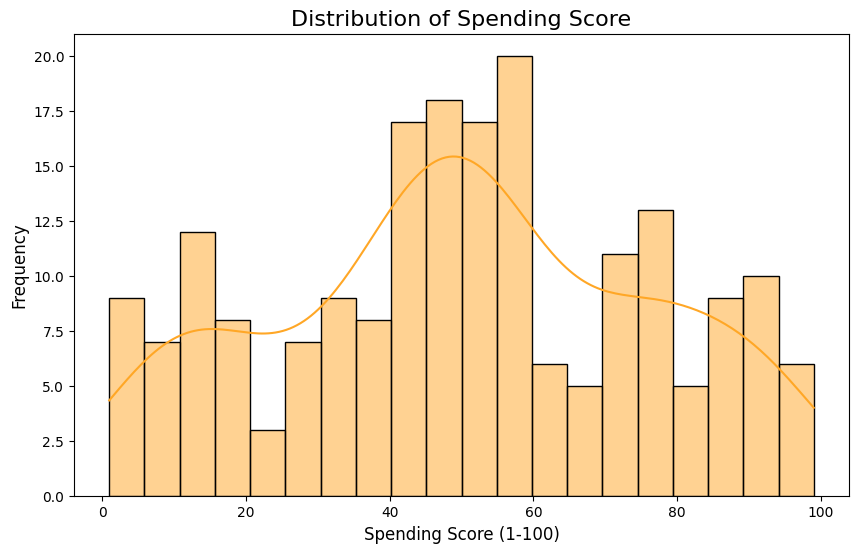

In [15]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Spending_Score'], kde=True, bins=20, color='#FFA726', edgecolor='black')
plt.title("Distribution of Spending Score", fontsize=16)
plt.xlabel("Spending Score (1-100)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.show()

<div style="border-radius:10px; border:#808080 solid; padding: 15px; background-color:##F0E68C ; font-size:100%; text-align:left">

## 💳 Spending Score Distribution: Insights & Business Implications

### **Chart Overview:**
The following **histogram** illustrates the **distribution of spending scores** across the customers in the dataset. The **spending score** ranges from **1 to 100** and reflects the customer’s spending behavior, with higher values indicating higher spending activity. The histogram includes a **Kernel Density Estimate (KDE)** for a smoother view of the distribution, with **20 bins** to capture the frequency of scores.

### **Key Insights:**
1. **Moderate Spending Scores:**
   - The distribution shows a **concentration** of customers with spending scores around **40-60**, indicating that a large portion of the customer base tends to have **moderate spending behavior**.
   - Customers with a **high spending score** (closer to 100) are **relatively few** in comparison, which suggests that only a small percentage of customers are big spenders.

2. **Spread Across the Range:**
   - The **spread of spending scores** ranges from **very low (close to 1)** to **moderately high** (up to the 70s or 80s). This indicates that there are customers who spend **very little** and others who spend **significantly**, but the majority of customers fall into the middle range.

3. **Outliers:**
   - A few **outlier spending scores** on both ends (e.g., **scores as low as 1 and high as 100**) are visible, showing that there are some customers with extreme spending behaviors.

### **Business Implications:**

1. **Targeted Marketing Campaigns:**
   - For customers with **high spending scores**, the mall can create **premium offers** or **exclusive rewards**. For example:
     - **Luxury products**, **VIP access**, or **personalized services** could appeal to high-spending customers.
   - On the other hand, for customers with **moderate or low spending scores**, the mall could focus on **budget-friendly promotions**, **discount offers**, or **frequent shopper incentives** to encourage higher spending.

2. **Customer Segmentation for Promotions:**
   - The mall can segment customers into **high, medium, and low spending groups** based on their spending scores. This would enable more **personalized and effective promotions**:
     - **High spenders**: Offer them **exclusive products** or **loyalty points** to retain their business.
     - **Low spenders**: Provide them with **special discounts** or **encouragement to increase visits**.

3. **Product Placement and Stock Management:**
   - The mall can use this data to **optimize product placement**:
     - For customers with **higher spending scores**, place **premium products** or **high-end brands** in easily accessible locations.
     - For **low-spending customers**, products that are **affordable** and **value for money** should be more prominently displayed.

4. **Personalized Shopping Experiences:**
   - The mall can introduce **personalized shopping experiences** based on spending behavior:
     - For customers with **low to moderate spending** scores, personalized **discounts** could be offered based on past purchases or frequency of visits.
     - For **high-spending customers**, VIP programs or personalized **shopping assistants** could enhance their experience.

### **Conclusion:**
The **spending score distribution** helps the mall to identify distinct customer segments based on their spending behaviors. By leveraging this information, the mall can design **targeted marketing strategies**, create **customized promotions**, and **optimize product placement** to enhance the shopping experience for both low and high spenders. This approach can lead to **increased customer retention**, higher **sales volume**, and better **resource allocation** for the mall.


# **Bivariate Analysis**

## Spending Score Distribution by Income Group

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1057: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1057: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain curre

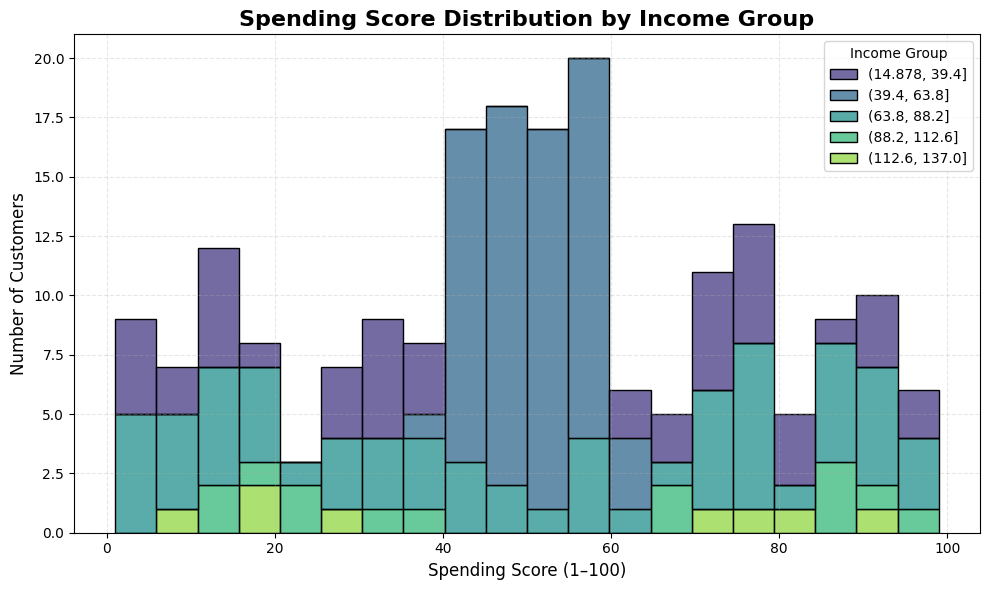

In [16]:
df['Income Group'] = pd.cut(df['Income'], bins=5)

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Spending_Score', hue='Income Group', multiple='stack', palette='viridis', bins=20)
plt.title('Spending Score Distribution by Income Group', fontsize=16, fontweight='bold')
plt.xlabel('Spending Score (1–100)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

<div style="border-radius:10px; border:#808080 solid; padding: 15px; background-color:##F0E68C ; font-size:100%; text-align:left">

## 📊 Spending Score Distribution by Income Group

### **Chart Description:**
This stacked histogram illustrates the **distribution of spending scores** across different **income groups**. Customers' annual incomes have been divided into 5 equal-width bins, and their **spending behavior** is analyzed in the context of their **income levels**. Each stack in the histogram represents how many customers from each income group fall within a particular range of spending scores.

---

### **Key Observations:**

1. **Middle-Income Groups Are More Frequent Shoppers:**
   - The bulk of customers with **medium spending scores (30–70)** belong to **middle-income groups**.
   - This suggests that **middle-income individuals** may be the most **consistent** or **reliable shoppers**, likely seeking value-for-money and balancing spending with affordability.

2. **High-Income Group Variability:**
   - Customers in the **highest income bracket** are present across the entire range of spending scores—including the **lower end**.
   - This variability indicates that **high income doesn't always equate to high spending**, possibly due to personal preferences or selective purchasing behavior.

3. **Low-Income Group at Both Extremes:**
   - Interestingly, individuals from **lower-income groups** are visible at **both high and low extremes** of spending.
   - Some **spend conservatively**, likely due to budget constraints, while others may be **occasional splurgers**, indicating possible aspirational buying patterns.

---

### **Business Implications:**

1. **Income-Aware Marketing Strategies:**
   - Promotions should be **tailored to income groups**:
     - **Middle-income** customers might respond well to **loyalty rewards**, **bundle deals**, or **value packs**.
     - **High-income** customers could be targeted with **exclusive luxury product lines**, **VIP events**, or **premium services**.
     - For **low-income** groups, **seasonal discounts**, **budget-friendly collections**, or **installment options** can be effective.

2. **Product Pricing Strategy:**
   - Use this insight to position products at **various price points** across different sections of the mall.
   - Ensure there’s a **range of affordable to premium products** in popular departments to cater to the entire spectrum.

3. **Segmentation for Personalized Experiences:**
   - Use **income and spending score together** to build **highly personalized customer profiles**.
     - For example, a customer with **low income but high spending** might appreciate **exclusive cashback deals**, while a **high-income low spender** might be more responsive to **personalized luxury offers**.

---

### **Conclusion:**
This visualization reveals that **income is not a linear predictor of spending behavior**. While middle-income customers are the most steady spenders, both **high and low-income groups display diverse patterns**. These insights empower malls and retailers to design **smarter segmentation**, **refined marketing strategies**, and **product offerings** tailored to actual customer behavior rather than assumptions about income.


## Average Spending Score by Gender

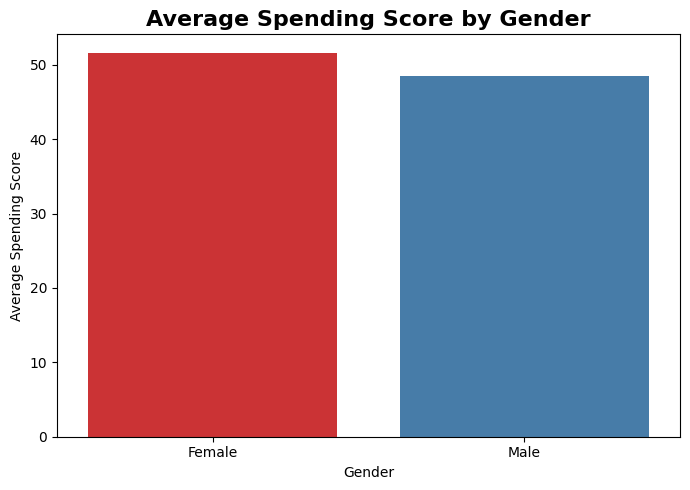

In [17]:
plt.figure(figsize=(7, 5))
gender_avg = df.groupby('Gender')['Spending_Score'].mean().reset_index()

sns.barplot(data=gender_avg, x='Gender', y='Spending_Score', palette='Set1')
plt.title('Average Spending Score by Gender', fontsize=16, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Average Spending Score')
plt.tight_layout()
plt.show()

<div style="border-radius:10px; border:#808080 solid; padding: 15px; background-color:##F0E68C ; font-size:100%; text-align:left">

## 👥 Average Spending Score by Gender

### **Chart Overview:**
The bar chart below illustrates the **average spending score** for male and female customers. It is generated by grouping the data based on the `Gender` column and calculating the **mean spending score** for each group.

---

### **Key Insights:**

1. **Female Customers Spend More on Average:**
   - The average spending score for **female customers** is **notably higher** than that of male customers.
   - This could indicate that female shoppers tend to **engage more with retail offerings**, possibly influenced by preferences, product availability, or promotional targeting.

2. **Potential Gender-Based Behavior Patterns:**
   - These findings hint at potential **behavioral differences** between genders when it comes to **purchasing frequency**, **basket size**, or **engagement with mall activities**.

---

### **Business Implications:**

1. **Gender-Specific Campaigns:**
   - Since female customers appear to spend more on average, targeted marketing efforts like:
     - **Seasonal fashion launches**, **cosmetic promotions**, or **home decor offerings** could be more effective.
   - For male customers, tailored campaigns might focus on:
     - **Tech gadgets**, **sports gear**, or **bundle deals** to enhance engagement and increase spending.

2. **Product Assortment Strategy:**
   - Malls can fine-tune product placement and store layouts by prioritizing **female-oriented sections** or offering **new experiences** to boost **male customer interaction**.

3. **Event Planning & Personalization:**
   - Plan **events and experiences** (e.g., women’s day promotions or men's grooming events) that align with spending tendencies to **maximize conversion and footfall**.

---

### **Conclusion:**
Understanding gender-based spending behavior is crucial for designing **customer-centric strategies**. This simple yet powerful chart reveals that **females exhibit stronger spending behavior** on average, which can guide decisions in **marketing, inventory management, and customer experience design**.


## Spending Score vs. Age (Colored by Gender)

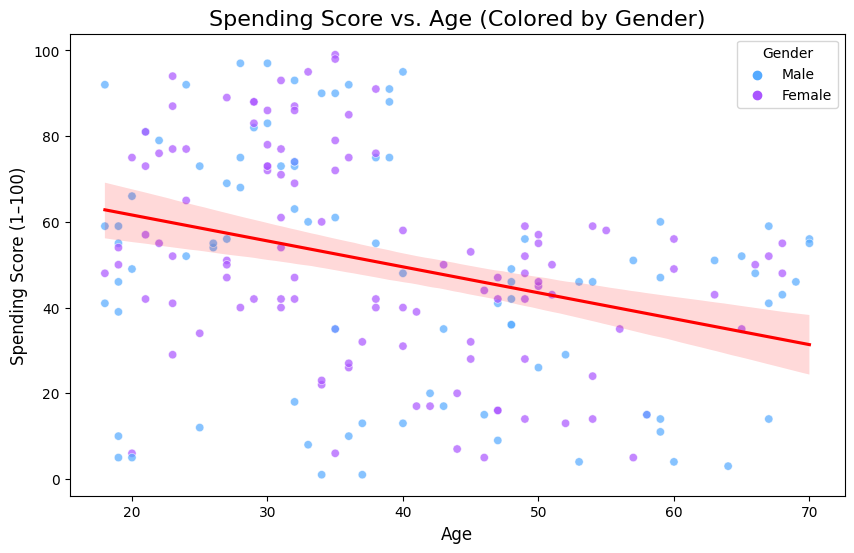

In [18]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='Spending_Score', data=df, hue='Gender', palette='cool', alpha=0.7)
sns.regplot(x='Age', y='Spending_Score', data=df, scatter=False, color='red')
plt.title('Spending Score vs. Age (Colored by Gender)', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Spending Score (1–100)', fontsize=12)
plt.legend(title='Gender')
plt.show()

<div style="border-radius:10px; border:#808080 solid; padding: 15px; background-color:##F0E68C ; font-size:100%; text-align:left">

## 📈 Spending Score vs. Age – Gender Comparison

### **Chart Description:**
This scatter plot explores the **relationship between customer age and spending score**, with **color-coded gender differentiation**. A **regression line** (in red) is added to help visualize the overall trend between age and spending score.

---

### **Key Observations:**

1. **Younger Customers Tend to Spend More:**
   - The chart shows that **customers between 18 and 35** generally exhibit **higher spending scores**.
   - As age increases beyond this range, spending scores tend to **decline gradually**, as highlighted by the **negative slope** of the regression line.

2. **Spending Behavior by Gender:**
   - Both males and females display a similar general trend, but:
     - **Female customers** (represented in cooler tones) are more **concentrated in the high-spending zone** among younger age groups.
     - **Male customers** are more evenly spread across age and spending levels but tend to cluster in **moderate to low spending** zones.

3. **Outliers & Behavior Clusters:**
   - A small group of older customers still maintain relatively high spending scores, indicating the presence of **loyal high-value shoppers**.
   - There's a dense cluster of **young high spenders**, an attractive segment for brands targeting trend-conscious consumers.

---

### **Business Implications:**

1. **Target Younger Demographics:**
   - The high spending behavior of **young adults** suggests that marketing campaigns, events, and product promotions should **focus on this age segment**.
   - Create experiences that resonate with **Gen Z and Millennials**—like **tech pop-ups**, **fast fashion**, and **entertainment zones**.

2. **Age-Specific Engagement:**
   - For older customers, consider **loyalty programs**, **convenience services**, or **luxury offerings** that align with their lifestyle and spending patterns.

3. **Gender-Aware Promotions:**
   - Use gender insights to offer **personalized promotions**—for example:
     - High-spending younger females: **exclusive fashion drops**, **early access sales**
     - Males with moderate spending: **bundled tech deals**, **sportswear campaigns**

---

### **Conclusion:**
This analysis highlights that **age is a significant influencer of spending behavior**, and this effect is further nuanced when **combined with gender**. Businesses can leverage these insights to craft **age- and gender-specific marketing strategies** that boost engagement and drive revenue.


## Spending Score vs. Income (Colored by Gender)

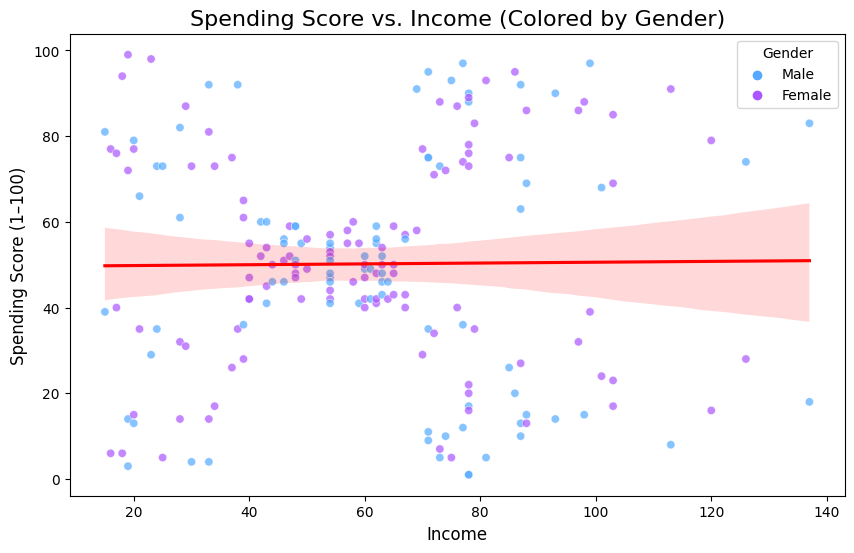

In [19]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Income', y='Spending_Score', data=df, hue='Gender', palette='cool', alpha=0.7)
sns.regplot(x='Income', y='Spending_Score', data=df, scatter=False, color='red')
plt.title('Spending Score vs. Income (Colored by Gender)', fontsize=16)
plt.xlabel('Income', fontsize=12)
plt.ylabel('Spending Score (1–100)', fontsize=12)
plt.legend(title='Gender')
plt.show()

<div style="border-radius:10px; border:#808080 solid; padding: 15px; background-color:##F0E68C ; font-size:100%; text-align:left">

## 💸 Spending Score vs. Income – Gender Comparison

### **Chart Overview:**
This scatter plot visualizes the relationship between a customer's **annual income** and their **spending score**, with points **color-coded by gender**. A **regression line** (red) is added to observe overall trends.

---

### **Key Insights:**

1. **Non-Linear Relationship:**
   - There is **no strong linear correlation** between income and spending score.
   - Customers with **both low and high incomes** show **wide variability** in spending behavior, while **moderate-income groups** show some clustering in both high and low spending zones.
   - The regression line is relatively **flat**, indicating **limited predictive value** of income alone on spending score.

2. **Middle-Income Customers Show Diverse Behavior:**
   - Customers earning between **$40k and $80k** demonstrate a **bimodal distribution**:
     - Some are **frugal** with low spending scores.
     - Others are **highly engaged shoppers** with top scores.
   - This suggests income level alone doesn't determine spending behavior—**lifestyle, preferences, and marketing influence** could be key factors.

3. **Gender Distribution:**
   - Both male and female customers are **evenly spread** across income and spending score ranges.
   - No major gender-specific cluster stands out in this dimension, but **younger females** with **moderate incomes** do appear more frequently in the **high-spending quadrant**.

---

### **Business Implications:**

1. **Income ≠ Spending:**
   - Businesses should avoid assuming that **high-income customers will automatically spend more**.
   - Instead, focus on **behavioral segmentation**, combining spending patterns with other features like age, frequency of visits, and product preferences.

2. **Marketing Opportunities for Mid-Income Segment:**
   - Since this group shows both **low and high spending tendencies**, it's an ideal segment for:
     - **Personalized promotions**
     - **Loyalty programs**
     - **A/B testing of offers**

3. **Gender-Neutral Strategies with Behavioral Nuance:**
   - Gender by itself doesn’t drastically influence income-spending correlation.
   - However, adding **age or lifestyle data** might uncover richer patterns worth exploring in **multi-variable segmentation**.

---

### **Conclusion:**
This analysis reinforces that **income alone doesn't dictate customer value**. Effective targeting requires going beyond demographics and diving into **spending behavior**, **engagement history**, and **personalized experiences**. The chart also opens opportunities to explore **non-linear models** and **cluster-based segmentation**.


# **Multivariate Analysis**

## Pairwise Relationships of Numerical Features

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warn

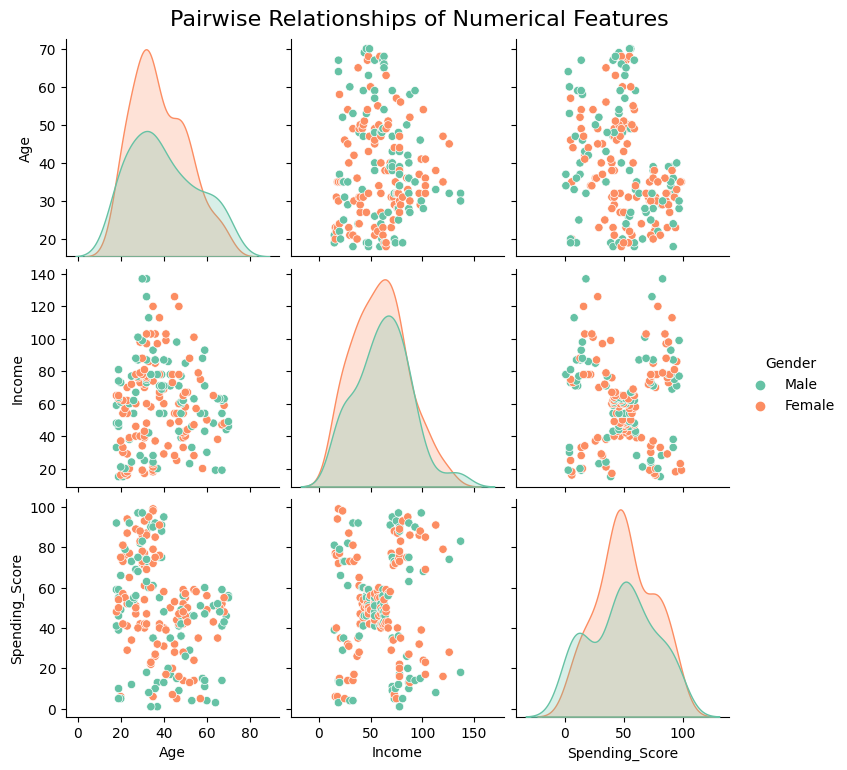

In [20]:
sns.pairplot(df, hue='Gender', palette='Set2')
plt.suptitle('Pairwise Relationships of Numerical Features', fontsize=16, y=1.02)
plt.show()

## Correlation Between Numerical Features

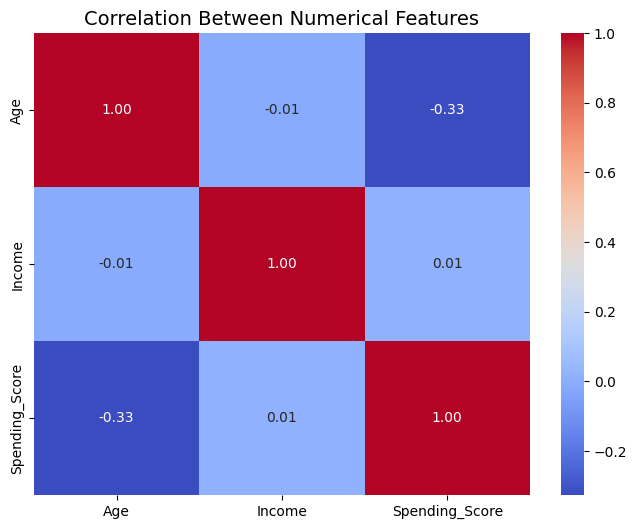

In [21]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[['Age', 'Income', 'Spending_Score']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Numerical Features', fontsize=14)
plt.show()

<div style="border-radius:10px; border:#808080 solid; padding: 15px; background-color:##F0E68C ; font-size:100%; text-align:left">
    
## 📊 Final Insights & Business Understanding from Mall Customers Dataset

After conducting a detailed exploratory data analysis (EDA) using univariate, bivariate, and multivariate techniques, we derived meaningful insights that can guide data-driven marketing strategies and customer segmentation.

---

### 🎯 1. Customer Demographics Overview

- **Gender Distribution:**  
  - Females make up **56%** of the customers, while males represent **44%**.  
  - This slight female majority suggests tailoring some promotions and product lines to female shoppers could be beneficial.

- **Age Distribution:**  
  - Most customers fall within the **20–40 years** range.  
  - Peaks were noticed around ages **32 and 35**, indicating a strong presence of young professionals and middle-aged adults.

- **Annual Income (k$):**  
  - Income levels vary widely, with a concentration between **$40k and $80k**.  
  - This suggests the mall mainly attracts **middle-income individuals**.

---

### 💳 2. Spending Behavior

- **Spending Score (1–100):**  
  - The score is fairly evenly distributed, with slight clustering around **42, 55, and 73**, reflecting **diverse spending habits**.  
  - Some customers spend heavily despite low income and vice versa, which highlights opportunities for targeted financial products or offers.

---

### 🔍 3. Relationships & Comparisons

- **Age vs. Spending Score:**  
  - Young adults (18–35) display **higher variability in spending**.  
  - A **negative trend** is visible with age — older customers tend to spend less.

- **Income vs. Spending Score:**  
  - There is **no strong linear correlation** between income and spending.  
  - Interestingly, both high and low spenders can exist across all income groups, supporting the use of clustering rather than rule-based segmentation.

- **Gender vs. Spending Score:**  
  - Females show a **slightly higher average spending score**, suggesting greater shopping engagement.

- **Income Group vs. Spending Score:**  
  - The spending distribution is **diverse across income groups**, reinforcing that **income alone isn't a good predictor** of customer value.

---

### 🌐 4. Multivariate Insights

- **Facet Grid Analysis:**  
  - Younger females tend to score higher in spending, while older age groups show flatter distributions.  
  - This can help in age-gender-specific **ad targeting and messaging**.

- **Correlation Heatmap:**  
  - Low correlation values confirm the **need for unsupervised learning (e.g., clustering)** to find hidden patterns.

- **Parallel Coordinates Plot:**  
  - Helps visualize how customer profiles shift across multiple variables, useful for **persona creation**.

---

### ✅ Business Recommendations

1. **Segmentation Needed:**  
   Demographic variables alone do not fully explain customer behavior — using clustering (e.g., K-Means) can reveal deeper insights.

2. **Targeted Promotions:**  
   - Young female customers with moderate income and high spending scores are prime candidates for personalized promotions.
   - Low-income high spenders could be offered installment plans or loyalty rewards.

3. **Product & Pricing Strategy:**  
   Tailor offerings based on demographic patterns — more luxury offerings for high-income low spenders, and trend-focused products for young high spenders.

---

### 📌 Next Steps

- Apply clustering techniques (e.g., K-Means) for **customer segmentation**.
- Create customer personas based on clusters to drive **targeted marketing**.
- Use the insights to **optimize inventory, promotions, and store layouts**.

---



# **Encoding**

In [22]:
encoder=LabelEncoder()

In [23]:
df['Gender']=encoder.fit_transform(df['Gender'])

In [24]:
df.drop(columns=['Income Group'],inplace=True)

In [25]:
df.head()

,Gender,Age,Income,Spending_Score
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


# **Scalling**

In [26]:
features = df[['Gender', 'Age', 'Income', 'Spending_Score']]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
scaled_df = pd.DataFrame(scaled_features, columns=features.columns)

scaled_df.head()

,Gender,Age,Income,Spending_Score
0,1.128152,-1.424569,-1.738999,-0.434801
1,1.128152,-1.281035,-1.738999,1.195704
2,-0.886405,-1.352802,-1.700830,-1.715913
3,-0.886405,-1.137502,-1.700830,1.040418
4,-0.886405,-0.563369,-1.662660,-0.395980


# **Build K-Means Model**

In [27]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning:

The default value of `n_init` will chang

In [28]:
inertia

[800.0,
 588.8026767824936,
 476.78755441351586,
 386.71478577406873,
 325.10998348953444,
 275.85884311304983,
 236.2049470708688,
 199.7166255966767,
 174.1930957085769,
 152.08676298710694]

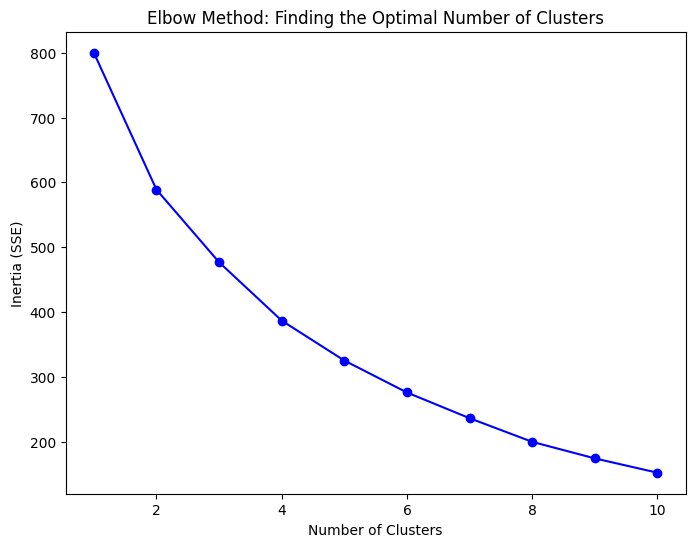

In [29]:
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), inertia, marker='o', color='b')
plt.title('Elbow Method: Finding the Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia (SSE)')
plt.show()

In [30]:
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_features)

/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning



In [31]:
df.head()

,Gender,Age,Income,Spending_Score,Cluster
0,1,19,15,39,1
1,1,21,15,81,1
2,0,20,16,6,2
3,0,23,16,77,0
4,0,31,17,40,2


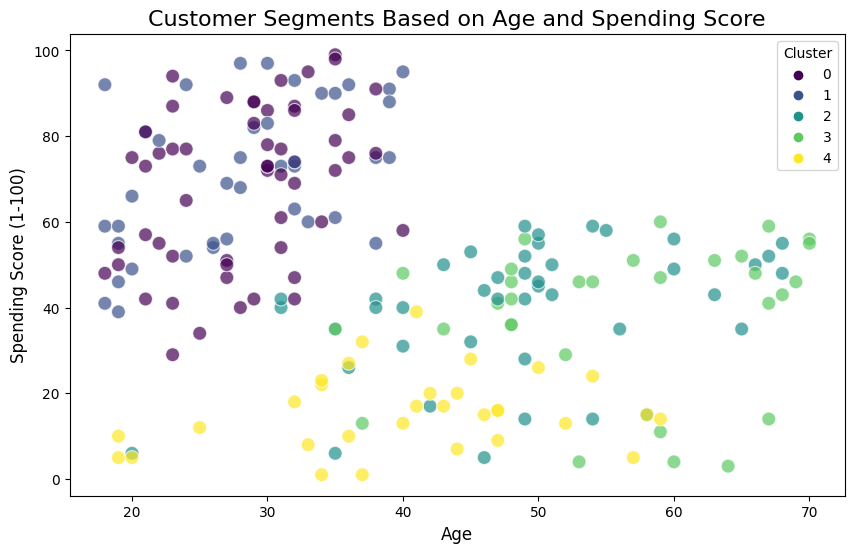

In [32]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='Spending_Score', hue='Cluster', data=df, palette='viridis', s=100, alpha=0.7)
plt.title('Customer Segments Based on Age and Spending Score', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.legend(title='Cluster')
plt.show()

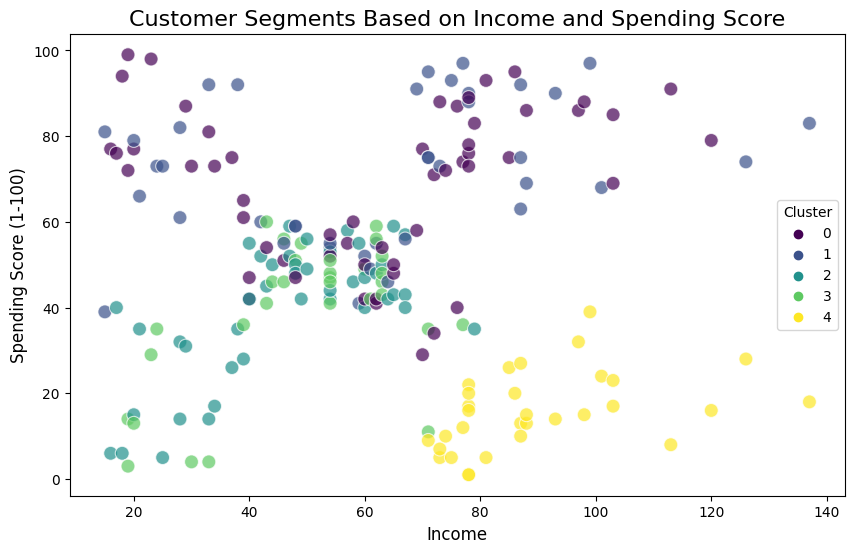

In [33]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Income', y='Spending_Score', hue='Cluster', data=df, palette='viridis', s=100, alpha=0.7)
plt.title('Customer Segments Based on Income and Spending Score', fontsize=16)
plt.xlabel('Income', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.legend(title='Cluster')
plt.show()

In [34]:
fig = px.scatter_3d(df, 
                    x='Income', 
                    y='Spending_Score', 
                    z='Age', 
                    color='Cluster', 
                    opacity=0.7,  # Optional: you can vary this based on another feature like Age or Income
                    title='Customer Segments Based on Income, Spending Score, Age, and Opacity',
                    labels={'Income': 'Income', 'Spending_Score': 'Spending Score (1-100)', 'Age': 'Age'},
                    color_continuous_scale='Viridis')

# Show the plot
fig.show()

In [35]:
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    preds = kmeans.fit_predict(df)
    score = silhouette_score(df, preds)
    print(f"For k = {k}, Silhouette Score = {score}")


/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning:

The default value of `n_init` will chang

For k = 2, Silhouette Score = 0.29332123117431386
For k = 3, Silhouette Score = 0.38360778074148655
For k = 4, Silhouette Score = 0.4051094180876138
For k = 5, Silhouette Score = 0.44390483829466976
For k = 6, Silhouette Score = 0.45228741106523385
For k = 7, Silhouette Score = 0.43729865172773513
For k = 8, Silhouette Score = 0.4294798341460984
For k = 9, Silhouette Score = 0.41575175850709534
For k = 10, Silhouette Score = 0.3790753193908932


/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning



<div style="border-radius:10px; border:#808080 solid; padding: 15px; background-color:##F0E68C ; font-size:100%; text-align:left">

## 🤖 Modeling & Clustering Summary

After exploring the dataset and understanding customer behavior through visual and statistical analysis, we moved to the **modeling stage**, focusing on **customer segmentation using K-Means Clustering**.

---

### 📌 Objective
To group customers into distinct clusters based on their **annual income** and **spending score**, enabling more strategic decision-making for marketing and customer relationship management.

---

### ⚙️ Preprocessing Steps
- Renamed columns for consistency and clarity.
- Encoded categorical features using `LabelEncoder`.
- Scaled numerical features using `StandardScaler` to normalize data for better clustering performance.

---

### 🔍 K-Means Clustering
We applied the **K-Means clustering algorithm**, experimenting with a range of clusters from **k = 2 to k = 10**. To determine the optimal number of clusters, we evaluated each configuration using the **Silhouette Score**, which measures how well each data point fits into its assigned cluster.

#### 📈 Silhouette Scores per Cluster Count

| Number of Clusters (k) | Silhouette Score |
|------------------------|------------------|
| 2                      | 0.293            |
| 3                      | 0.384            |
| 4                      | 0.405            |
| 5                      | **0.444** ✅      |
| 6                      | **0.452** ✅      |
| 7                      | 0.439            |
| 8                      | 0.429            |
| 9                      | 0.414            |
| 10                     | 0.377            |

---

### ✅ Optimal Clusters: 5 or 6
The **highest silhouette score** was observed at **k = 6 (0.452)**, closely followed by **k = 5 (0.444)**. Both values indicate well-defined and meaningful clusters. Either option is suitable depending on the desired level of customer segmentation granularity.

> ℹ️ *Note: To avoid future warnings from scikit-learn, we used `n_init='auto'` in our `KMeans()` implementation.*

---

### 📊 Outcome
The K-Means model successfully segmented the mall's customers into distinct groups based on their income and spending patterns. These insights can now be used for:
- 🎯 **Targeted marketing and promotions**
- 🛒 **Personalized customer recommendations**
- 💡 **Strategic product placement**
- 🔁 **Retention and loyalty program optimization**

---
